# Lecture 12. Hands-on with e3nn-jax

**PHYG004 · Sogang University · 2026 Spring**
**Instructor:** Prof. Young Woo Choi

## Today's mission

Replace the scalar messages of L11's SchNet by **direction-aware tensorial messages** built from spherical harmonics, and reproduce one experiment from Thomas et al. 2018, *Tensor Field Networks* (Section 4.1, [arXiv:1802.08219](https://arxiv.org/abs/1802.08219)).

The setup. The same eight 4-atom shapes used on Wednesday, including the chiral pair.

The result.

1. The equivariant network classifies all 8 shapes correctly from one training example per shape — including the chiral pair.
2. After random rotation of the test inputs, accuracy stays at 100%.
3. Both failure modes diagnosed in L11 (rotation, chirality) disappear in one stroke.

![rotated molecule. Equivariant network produces correctly rotated forces. Vanilla MLP outputs random forces.](https://yw-choi.github.io/PHYG004/lectures/12/images/00_motivation.png)

## Where we left off (L11)

L11 built two non-equivariant baselines on this exact dataset.

| Model | train acc | rotated-test acc | chiral pair |
|---|---|---|---|
| flat-coordinate MLP | 100% | ~12% (random) | overfits, but useless on rotation |
| SchNet (distance-only MPNN) | 87.5% | 87.5% | logits identical — invisible |

Two failure modes traced to architectural choices.

* Flat coordinates are *rotation-sensitive but unstructured*. The MLP has to learn rotation behavior from 8 examples; it cannot.
* Pairwise distances are *rotation-invariant but parity-symmetric*. SchNet sees `chiral_1` and `chiral_2` as the same input.

The cure is one design move: replace the SchNet message
$$m_{ij}^{\text{SchNet}} \;=\; \big(W^{(s)} h_j\big) \odot \mathrm{MLP}\big(\mathrm{RBF}(r_{ij})\big)$$
by the equivariant message
$$m_{ij}^{\text{equiv}} \;=\; h_j \;\otimes\; Y_\ell\!\big(\hat r_{ij}\big),$$
which exposes the bond *direction* via spherical harmonics. The remainder of today builds the math machinery needed to make sense of this expression.

## Why equivariance matters at scale

Standard neural networks treat a rotated copy of a molecule as a brand-new input. To handle rotation there are two routes.

**Option 1. Data augmentation.** Train on many rotated copies. Simple. Inefficient. No exact guarantee on unseen rotations.

**Option 2. Build rotation into the architecture.** Correct on every rotation by construction. More work to implement; exactly correct.

Today we do option 2 in its smallest form. The same idea drives NequIP (2022), MACE (2022), and MACE-MP-0 (2023), which beat non-equivariant baselines on molecular benchmarks by 100 to 1000 times in data efficiency.

## Source

* Reference code. [`e3nn-jax/examples/tetris_point.py`](https://github.com/e3nn/e3nn-jax/blob/main/examples/tetris_point.py)
* Library docs. <https://e3nn-jax.readthedocs.io/>
* TFN paper. <https://arxiv.org/abs/1802.08219>

## Runtime

Use **Colab CPU**. Tetris has only 8 examples. GPU setup adds latency without speedup.


## Cell 1. Install packages

Four small packages.

* `e3nn-jax`. The equivariant-neural-network library. The main tool today.
* `flax`. A thin neural-network wrapper around JAX.
* `optax`. JAX optimizers like Adam.
* `jraph`. JAX graph utilities. We use a small piece.

**Do not install `jax` itself.** Colab already ships a matched `jaxlib`. Reinstalling can break GPU support.


In [1]:
!pip install -q "e3nn-jax>=0.20.8,<0.22" flax optax jraph tqdm matplotlib

zsh:1: command not found: pip


## Cell 2. Imports and setup

Two non-default settings.

1. **float64 mode.** The equivariance checks below verify two computations agree to about $10^{-15}$, which is float64 precision. Float32 cannot resolve this.
2. **Fixed random seed.** For reproducibility across runs.


In [2]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import e3nn_jax as e3nn
import flax.linen as nn
import jraph
import optax
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
key = jax.random.PRNGKey(SEED)

print("jax version  :", jax.__version__)
print("e3nn-jax     :", e3nn.__version__)
print("devices      :", jax.devices())
print("default dtype:", jnp.zeros(1).dtype)

jax version  : 0.10.0
e3nn-jax     : 0.21.0
devices      : [CpuDevice(id=0)]
default dtype: float64


## Cell 3. What does "rotation" mean in code

A 3D rotation is a $3 \times 3$ matrix $R$. To rotate a vector $\vec v$, multiply.

$$\vec v \;\longmapsto\; R\,\vec v$$

A valid rotation has two properties.

**Length preserving.** Rotation does not stretch or shrink.

$$|R\vec v| \;=\; |\vec v|$$

**Orthogonal.** The transpose is the inverse.

$$R^\top R \;=\; I$$

`e3nn.rand_matrix` returns a uniformly random rotation. The cell below builds one and checks both properties hold to machine precision.

![a vector $\vec v$ and its rotated image $R\vec v$ on the same sphere.](https://yw-choi.github.io/PHYG004/lectures/12/images/03_rotation_vector.png)


In [3]:
k1, k2 = jax.random.split(key)

R: jnp.ndarray = e3nn.rand_matrix(k1)        # (3, 3) rotation matrix
v: jnp.ndarray = jax.random.normal(k2, (3,))
v = v / jnp.linalg.norm(v)                   # unit vector

Rv = R @ v

print(f"R       shape: {R.shape}")
print(f"v       shape: {v.shape}")
print(f"Rv      shape: {Rv.shape}")
print(f"|Rv|         : {jnp.linalg.norm(Rv):.6f}  (should be 1)")
print(f"|R^T R - I|  : {jnp.linalg.norm(R.T @ R - jnp.eye(3)):.2e}  (should be ~0)")

R       shape: (3, 3)
v       shape: (3,)
Rv      shape: (3,)
|Rv|         : 1.000000  (should be 1)
|R^T R - I|  : 1.12e-07  (should be ~0)


## Cell 4. Spherical harmonics, by picture

*Optional but worth five minutes.*

A core ingredient of equivariant networks is a family of functions called **spherical harmonics**, written

$$Y_\ell^m(\hat r), \qquad \ell = 0, 1, 2, \ldots, \quad m = -\ell, \ldots, +\ell.$$

You have seen these in quantum mechanics. They are the angular part of the $s, p, d, f$ orbitals.

Forget the formulas for now. Picture each $Y_\ell^m$ as a function that takes a unit direction $\hat r$ and returns a number. There are $2\ell + 1$ of them at each $\ell$.

| $\ell$ | number of functions | shape |
|---|---|---|
| 0 | 1 | constant. Like $s$. |
| 1 | 3 | proportional to $x$, $y$, $z$. Like $p$. |
| 2 | 5 | $d$-orbitals. |
| 3 | 7 | $f$-orbitals. |

The cell below draws the five $\ell = 2$ functions on a sphere. They look like $d$-orbitals because they are.

Why we care. When you rotate the input direction $\hat r$, the $\ell = 2$ functions mix only among themselves. They do not leak into $\ell = 0, 1, 3, \ldots$. That clean separation is the foundation of equivariance. The next cell verifies it numerically.

![the spherical harmonic zoo for $\ell = 0, 1, 2, 3$.](https://yw-choi.github.io/PHYG004/lectures/12/images/04_sh_zoo.png)


rhat shape: (60, 120, 3)
sh irreps : 1x1o+1x2e+1x3o  (lmax=3)
sh shape  : (60, 120, 15)  (last dim = 3 + 5 + 7 = 15)


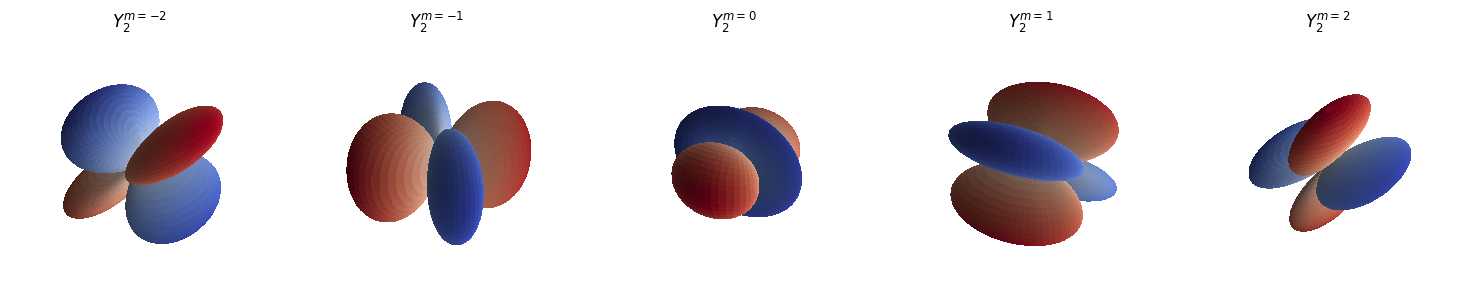

In [4]:
# Sample a grid of points on the sphere
n_theta, n_phi = 60, 120
theta = jnp.linspace(0.0, jnp.pi, n_theta)
phi = jnp.linspace(0.0, 2 * jnp.pi, n_phi)
th, ph = jnp.meshgrid(theta, phi, indexing="ij")
x = jnp.sin(th) * jnp.cos(ph)
y = jnp.sin(th) * jnp.sin(ph)
z = jnp.cos(th)
rhat = jnp.stack([x, y, z], axis=-1)         # (n_theta, n_phi, 3)
rhat = e3nn.IrrepsArray("1o", rhat)         # tag these as 3-vectors (1o)
print(f"rhat shape: {rhat.array.shape}")

# spherical_harmonics returns an IrrepsArray with irreps "1o + 2e + 3o"
sh = e3nn.spherical_harmonics([1, 2, 3], rhat, normalize=True)
print(f"sh irreps : {sh.irreps}  (lmax={sh.irreps.lmax})")
print(f"sh shape  : {sh.array.shape}  (last dim = 3 + 5 + 7 = 15)")

# The l=2 block is at offset 3..8 in the array (after the l=1 block of size 3)
y2 = np.asarray(sh.array[..., 3:8])

fig, axes = plt.subplots(1, 5, figsize=(15, 3), subplot_kw={"projection": "3d"})
for m, ax in enumerate(axes):
    val = y2[..., m]
    r_plot = np.abs(val)
    ax.plot_surface(
        r_plot * np.asarray(x), r_plot * np.asarray(y), r_plot * np.asarray(z),
        facecolors=plt.cm.coolwarm((val - val.min()) / (val.max() - val.min() + 1e-12)),
        rstride=1, cstride=1, antialiased=False, linewidth=0,
    )
    ax.set_title(f"$Y_2^{{m={m-2}}}$")
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## Cell 5. The promise. Spherical harmonics know how to rotate

✅ **Checkpoint A**

Notation. Let $\hat r$ denote a unit vector in 3D. For a fixed $\ell$, stack the $2\ell+1$ spherical harmonics into a column vector,

$$Y_\ell(\hat r) \;=\; \big(\, Y_\ell^{-\ell}(\hat r),\; Y_\ell^{-\ell+1}(\hat r),\; \ldots,\; Y_\ell^{+\ell}(\hat r) \,\big)^{\!\top}.$$

So $Y_\ell(\hat r)$ is a vector with $2\ell+1$ entries.

Let $R$ be a rotation matrix (a $3 \times 3$ orthogonal matrix, as in Cell 3). The crucial property is this. Rotating $\hat r$ first and then evaluating $Y_\ell$ gives the same answer as evaluating $Y_\ell$ first and then multiplying by a fixed matrix that depends only on $R$ and $\ell$.

$$\boxed{\;Y_\ell(R\,\hat r) \;=\; D^\ell(R)\,Y_\ell(\hat r)\;}$$

Symbols.

* $D^\ell(R)$ is a $(2\ell+1) \times (2\ell+1)$ matrix called the **Wigner-D matrix**. It is determined entirely by $R$ and $\ell$.
* The library `e3nn-jax` builds $D^\ell(R)$ from $R$ for us. We never need the explicit formula.

Why this property matters. It is the foundation everything else rests on. Spherical harmonics behave predictably under rotation, so layers built on top of them inherit that behavior.

The cell below computes both sides numerically. They should agree to about $10^{-15}$.

![commutative diagram for spherical harmonic equivariance.](https://yw-choi.github.io/PHYG004/lectures/12/images/05_equivariance_diagram.png)


In [5]:
# Random unit vector and a random rotation
k1, k2 = jax.random.split(jax.random.PRNGKey(7))
rhat = jax.random.normal(k1, (16, 3))
rhat = rhat / jnp.linalg.norm(rhat, axis=-1, keepdims=True)
rhat = e3nn.IrrepsArray("1o", rhat)         # tag as 1o IrrepsArray
R = e3nn.rand_matrix(k2)

# Method 1: SH at rotated coordinates
lmax = 3
Y_at_Rr = e3nn.spherical_harmonics(list(range(1, lmax + 1)), rhat.transform_by_matrix(R), normalize=True)

# Method 2: SH at original coords, then library applies D^l(R)
Y_at_r = e3nn.spherical_harmonics(list(range(1, lmax + 1)), rhat, normalize=True)
Y_rotated = Y_at_r.transform_by_matrix(R)

diff = jnp.max(jnp.abs(Y_at_Rr.array - Y_rotated.array))
print(f"max |Y(R r) - D(R) Y(r)| = {diff:.2e}")
assert diff < 1e-8, "equivariance violated. something is wrong"
print("✅ Checkpoint A: equivariance of spherical harmonics holds")

max |Y(R r) - D(R) Y(r)| = 1.33e-15
✅ Checkpoint A: equivariance of spherical harmonics holds


## Cell 6. Tagging features with their rotation type. `Irreps`

In an ordinary neural network, the input is a flat array of numbers. The model has no idea what each number means.

In an equivariant network, we tag groups of numbers with their **rotation type**.

| Tag | Meaning | Physics example |
|---|---|---|
| `0e` | scalar. Rotation does nothing. | energy, charge, temperature |
| `1o` | polar vector. Rotates with $R$. Odd parity. | position, momentum, force |
| `1e` | axial vector. Rotates with $R$. Even parity. | angular momentum, magnetic field |
| `2e` | symmetric rank-2 tensor. | stress, polarizability |

The `e` and `o` mean **even** and **odd** under reflection. We need this distinction for the chiral pair later. For now treat them as labels.

The string

```
"32x0e + 8x1o + 8x2e"
```

declares a feature with 32 scalars, 8 polar vectors, and 8 rank-2 tensors. Total

$$32 \cdot 1 + 8 \cdot 3 + 8 \cdot 5 \;=\; 96 \text{ numbers}.$$

Once the network knows the layout, it applies the right rotation rule to each block.

Think of `Irreps` as the equivariant analogue of `int`, `float`, `str` in regular code.

![layout of a 96-number feature with type tags.](https://yw-choi.github.io/PHYG004/lectures/12/images/06_irreps_layout.png)


In [6]:
irreps = e3nn.Irreps("32x0e + 8x1o + 8x2e")
print(f"irreps          : {irreps}")
print(f"total dim       : {irreps.dim}        (= 32*1 + 8*3 + 8*5 = 96)")
print(f"lmax            : {irreps.lmax}")
print(f"num irreps      : {len(irreps)}")
print(f"slices          : {irreps.slices()}")

# Compare to a non-equivariant view: 96 raw scalars (no symmetry information)
vanilla = e3nn.Irreps("96x0e")
print(f"\nA vanilla 96-dim feature would be: {vanilla}")
print("Same dim, but the equivariant declaration above carries 8 vectors and 8 rank-2 channels with known rotation behavior.")

irreps          : 32x0e+8x1o+8x2e
total dim       : 96        (= 32*1 + 8*3 + 8*5 = 96)
lmax            : 2
num irreps      : 3
slices          : [slice(0, 32, None), slice(32, 56, None), slice(56, 96, None)]

A vanilla 96-dim feature would be: 96x0e
Same dim, but the equivariant declaration above carries 8 vectors and 8 rank-2 channels with known rotation behavior.


## Cell 7. Combining two vectors, the equivariant way

✅ **Checkpoint B**

Setup. Take two 3-vectors

$$\vec a \;=\; (a_1, a_2, a_3), \qquad \vec b \;=\; (b_1, b_2, b_3),$$

where the subscript $i \in \{1, 2, 3\}$ is the component index ($1 = x$, $2 = y$, $3 = z$). We want to combine $\vec a$ and $\vec b$ into a single feature.

A plain network would `concat` and pass through a `Dense` layer. The result loses its rotation type.

In an equivariant network there are exactly three rotation-respecting ways to combine two vectors.

| Combination | Component form | Output type | Numbers |
|---|---|---|---|
| **Dot product** | $\vec a \cdot \vec b \;=\; \sum_{i=1}^{3} a_i b_i$ | scalar `0e` | 1 |
| **Cross product** | $(\vec a \times \vec b)_k \;=\; \sum_{ij} \varepsilon_{kij}\,a_i b_j$ | axial vector `1e` | 3 |
| **Traceless symmetric** | $T_{ij} \;=\; \tfrac{1}{2}(a_i b_j + a_j b_i) \;-\; \tfrac{1}{3}(\vec a \cdot \vec b)\,\delta_{ij}$ | rank-2 `2e` | 5 |

Symbols used in the formulas.

* $\delta_{ij}$ is the Kronecker delta. It equals $1$ if $i = j$ and $0$ otherwise.
* $\varepsilon_{kij}$ is the Levi-Civita symbol. It equals $+1$ for an even permutation of $(1,2,3)$, $-1$ for an odd permutation, and $0$ if any two indices are equal.
* The dot, cross, and traceless symmetric pieces sum to $1 + 3 + 5 = 9$ numbers, the same count as the $3 \times 3$ matrix with entries $a_i b_j$.

These three are the **only** ways to combine two vectors equivariantly. The proof is the Clebsch-Gordan decomposition.

Two more symbols, used everywhere from now on.

* $\otimes$ is the equivariant tensor product. Applied to two features it produces all the rotation-respecting combinations and packages them into one new feature.
* $\oplus$ is the direct sum. It concatenates feature blocks of different irrep types.

In compact form,

$$\boxed{\;\mathbf{1o} \otimes \mathbf{1o} \;=\; \mathbf{0e} \;\oplus\; \mathbf{1e} \;\oplus\; \mathbf{2e}\;}$$

which reads "the tensor product of two polar vectors splits into a scalar, an axial vector, and a rank-2 traceless symmetric tensor".

`e3nn.tensor_product(a, b)` computes all three at once and returns one `IrrepsArray` with irreps `"0e + 1e + 2e"`.

The cell below verifies the `0e` channel really is the dot product, up to a normalization $1/\sqrt{3}$ that the library uses by default.

![tensor product of two vectors decomposed into 0e, 1e, 2e.](https://yw-choi.github.io/PHYG004/lectures/12/images/07_tensor_product.png)


In [7]:
k1, k2 = jax.random.split(jax.random.PRNGKey(11))
a_data = jax.random.normal(k1, (3,))
b_data = jax.random.normal(k2, (3,))

a = e3nn.IrrepsArray("1o", a_data)
b = e3nn.IrrepsArray("1o", b_data)

ab = e3nn.tensor_product(a, b)
print(f"a       irreps : {a.irreps}")
print(f"a.shape         : {a.array.shape}")
print(f"a ⊗ b   irreps : {ab.irreps}")
print(f"(a ⊗ b).shape   : {ab.array.shape}  (= 1 + 3 + 5 = 9 numbers)")

# Slice into the three irrep blocks
scalar = ab.array[..., 0:1]   # 0e block (1 value)
vector = ab.array[..., 1:4]   # 1e block (3 values, the cross product up to sign/norm)
tensor = ab.array[..., 4:9]   # 2e block (5 values)

dot = jnp.dot(a_data, b_data)
cross = jnp.cross(a_data, b_data)

print(f"\n0e channel        : {scalar.squeeze():.6f}")
print(f"a · b / sqrt(3)   : {dot / jnp.sqrt(3.0):.6f}")
ratio_0e = scalar.squeeze() / (dot / jnp.sqrt(3.0))
print(f"ratio              : {ratio_0e:.6f}  (should be 1.0)")
assert jnp.abs(ratio_0e - 1.0) < 1e-6, "0e channel does not match (a·b)/sqrt(3)"
print("\n✅ Checkpoint B: 0e channel of (a ⊗ b) equals (a·b)/sqrt(3) as expected")

# Quick filter API demo
scalar_only = e3nn.tensor_product(a, b, filter_ir_out=[e3nn.Irrep("0e")])
print(f"\nfilter_ir_out=[0e] gives irreps: {scalar_only.irreps}")

a       irreps : 1x1o
a.shape         : (3,)
a ⊗ b   irreps : 1x0e+1x1e+1x2e
(a ⊗ b).shape   : (9,)  (= 1 + 3 + 5 = 9 numbers)

0e channel        : -2.282282
a · b / sqrt(3)   : -2.282282
ratio              : 1.000000  (should be 1.0)

✅ Checkpoint B: 0e channel of (a ⊗ b) equals (a·b)/sqrt(3) as expected

filter_ir_out=[0e] gives irreps: 1x0e


## Cell 8. The 8 shapes from the TFN paper

The actual training data.

We reproduce the figure from Thomas et al. 2018, Section 4.1. Eight shapes, each made of 4 atoms at integer grid positions.

| Label | Name | Description |
|---|---|---|
| 0 | `chiral_1` | chiral shape, one specific handedness |
| 1 | `chiral_2` | mirror image of `chiral_1` |
| 2 | `square` | flat $2 \times 2$ square |
| 3 | `line` | 4 atoms in a line |
| 4 | `corner` | three legs from a corner |
| 5 | `L` | L-shape |
| 6 | `T` | T-shape |
| 7 | `zigzag` | zigzag |

The chiral pair (labels 0 and 1) is the difficult test. They are mirror images. No rotation maps one onto the other. To tell them apart, the network must be sensitive to reflection on top of rotation.

That sensitivity comes from a special feature channel called `0o`, a **parity-odd scalar**. We see this channel in the model's last layer in Cell 9.

Run the cell to see all 8 shapes in 3D. Try to spot the chiral pair by eye.

![the 8 shapes, with the mirror pair circled.](https://yw-choi.github.io/PHYG004/lectures/12/images/08_tetris_shapes.png)


pos shape   : (8, 4, 3)  (8 shapes, 4 atoms, 3 coords)


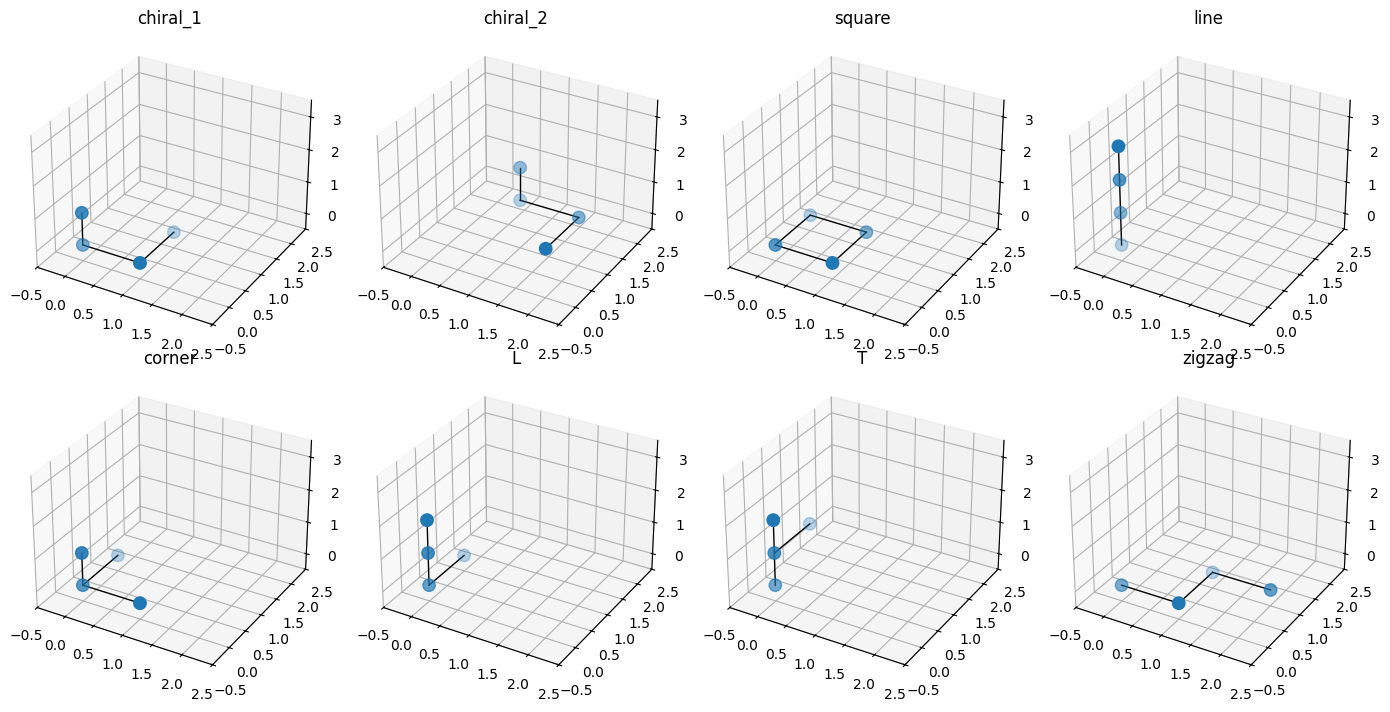

In [8]:
shape_names = ["chiral_1", "chiral_2", "square", "line", "corner", "L", "T", "zigzag"]
pos = jnp.array([
    [[0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]],   # chiral_shape_1
    [[1, 1, 1], [1, 1, 2], [2, 1, 1], [2, 0, 1]],   # chiral_shape_2  (mirror)
    [[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0]],   # square
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 0, 3]],   # line
    [[0, 0, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0]],   # corner
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 0]],   # L
    [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 1]],   # T
    [[0, 0, 0], [1, 0, 0], [1, 1, 0], [2, 1, 0]],   # zigzag
], dtype=jnp.float64)
labels = jnp.arange(8)
print(f"pos shape   : {pos.shape}  (8 shapes, 4 atoms, 3 coords)")

fig = plt.figure(figsize=(14, 7))
for i, name in enumerate(shape_names):
    ax = fig.add_subplot(2, 4, i + 1, projection="3d")
    p = np.asarray(pos[i])
    ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=80)
    # draw bonds where atoms are within distance 1.1
    for a_idx in range(4):
        for b_idx in range(a_idx + 1, 4):
            if np.linalg.norm(p[a_idx] - p[b_idx]) < 1.1:
                ax.plot(*zip(p[a_idx], p[b_idx]), color="black", lw=1)
    ax.set_title(name)
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.5); ax.set_zlim(-0.5, 3.5)
plt.tight_layout(); plt.show()

For training we package each shape as a small graph. Atoms are nodes, atom-pairs within distance 1.1 are edges. All 8 shapes are stacked into one `jraph.GraphsTuple` for batched processing.

The helper below is standard graph-batching code. Skim it.


In [9]:
def make_tetris_graphs() -> jraph.GraphsTuple:
    graphs = []
    for p, lab in zip(pos, labels):
        senders, receivers = e3nn.radius_graph(p, 1.1)
        graphs.append(jraph.GraphsTuple(
            nodes=p.reshape((4, 3)),
            edges=None,
            globals=lab[None],
            senders=senders,
            receivers=receivers,
            n_node=jnp.array([4]),
            n_edge=jnp.array([len(senders)]),
        ))
    return jraph.batch(graphs)

graphs = make_tetris_graphs()
print(f"total nodes : {graphs.n_node.sum()}")
print(f"total edges : {graphs.n_edge.sum()}")
print(f"labels      : {graphs.globals}")

total nodes : 32
total edges : 50
labels      : [0 1 2 3 4 5 6 7]


## Cell 9. From SchNet to the equivariant message

Side-by-side, one design move, four substitutions.

| Component | SchNet (L11) | Equivariant (today) |
|---|---|---|
| Node feature $h_i$ | scalar vector $\mathbb{R}^d$ | `IrrepsArray`, e.g. `32x0e + 8x1o + 8x2e` (Cell 6) |
| Edge feature | $\mathrm{RBF}(r_{ij})$ — depends on $\|\vec r_{ij}\|$ only | $Y_\ell(\hat r_{ij})$ — depends on the *direction* (Cells 4–5) |
| Combine $h_j$ with edge | elementwise gate $\big(W h_j\big) \odot \mathrm{MLP}(\mathrm{RBF})$ | tensor product $h_j \otimes Y_\ell(\hat r_{ij})$ (Cell 7) |
| Aggregation | $\sum_j$ over neighbors | $\sum_j$ over neighbors (unchanged) |
| Update | linear + scalar nonlinearity | equivariant linear + scalar activation |

The full message-passing recipe stays the same — message $\to$ aggregate $\to$ update from L11 — but every operation is replaced by an irrep-aware version. The aggregation operator $\sum$ is identical in both: summing irreps of the same type is equivariant.

**What this gains.**

* Direction. $Y_\ell(\hat r_{ij})$ for $\ell \geq 1$ encodes the angular geometry between atom $i$ and atom $j$, which $\mathrm{RBF}(r_{ij})$ throws away.
* Parity. Odd-$\ell$ spherical harmonics flip sign under reflection. Carrying parity-odd channels (`1o`, `3o`, …) all the way to the output gives the model a quantity that distinguishes mirror images — the missing piece in L11's SchNet.

**What stays the same.**

* The graph topology (atoms = nodes, neighbours within cutoff = edges) is identical to L11.
* The three-step MPNN template from Gilmer et al. 2017 is unchanged.

The remainder of the notebook builds the network exactly along this template. Cell 10 puts the message construction inside a `jraph.GraphNetwork` layer, stacks two such layers, and reads out 8 class logits with a chirality-aware head built from a `0o` channel.

![SchNet message vs equivariant message](https://yw-choi.github.io/PHYG004/lectures/12/images/bridge_schnet_to_equivariant.png)


## Cell 10. Training the equivariant network

✅ **Checkpoint C**

The model is built from two stacked equivariant layers followed by a classifier head. We spell out one layer first, then the head.

### One equivariant layer, in full

Notation. Inside one molecule, atoms are indexed by $i, j, k, \ldots$.

* $\vec r_i \in \mathbb{R}^3$ is the position of atom $i$.
* $\vec r_{ij} \;=\; \vec r_j - \vec r_i$ is the bond vector pointing from atom $i$ to atom $j$.
* $r_{ij} \;=\; |\vec r_{ij}|$ is the bond length.
* $\hat r_{ij} \;=\; \vec r_{ij} / r_{ij}$ is the unit direction of the bond.
* $h_i$ is the feature carried by atom $i$. It is an `IrrepsArray`, so it is a labeled bundle of scalars, vectors, and tensors (the type tags from Cell 6).
* $r_c$ is a fixed cutoff distance. We use $r_c = 1.1$ here, just enough to connect atoms one grid unit apart. Note that L11 used a fully-connected graph ($r_c = 4$); the equivariant model does not need long-range edges because direction information already breaks the path-graph degeneracy that forced the larger cutoff in SchNet.
* $\mathcal{N}(i) \;=\; \{\, j \;:\; r_{ij} < r_c \,\}$ is the neighborhood of atom $i$, the set of atoms within $r_c$.

The recipe. For each ordered pair $(i, j)$ with $j \in \mathcal{N}(i)$, the message from sender $j$ to receiver $i$ is

$$m_{ij} \;=\; h_j \;\otimes\; Y_\ell(\hat r_{ij}).$$

Reading the symbols.

* $h_j$ is the feature at the sender atom $j$.
* $Y_\ell(\hat r_{ij})$ is the column vector of spherical harmonics from Cell 4, evaluated at the unit bond direction. In this model the library stacks $\ell = 1, 2, 3$ together inside one IrrepsArray.
* $\otimes$ is the equivariant tensor product from Cell 7. It mixes "what feature the sender has" with "in which direction the bond points" into a new feature whose irrep types are determined by the Clebsch-Gordan rule.

The receiver atom collects messages from all its neighbors,

$$h_i^{\text{new}} \;=\; \sum_{j \in \mathcal{N}(i)} m_{ij}.$$

The aggregated feature $h_i^{\text{new}}$ is then passed through

1. a learnable **equivariant linear layer**, which mixes the multiplicities of each irrep without changing the type, then
2. a **scalar activation**, a non-linearity that acts only on the `0e`/`0o` channels and leaves higher-$\ell$ channels untouched. This is the simplest equivariant non-linearity; production models such as NequIP and MACE use a *gate activation* that propagates non-linearity to higher $\ell$ via a learnable scalar gate.

Every step is equivariant by construction. The network never sees a rotated copy of any training shape.

### Output head and chirality

After two stacked layers, the last layer is shaped to output irreps `"0o + 7x0e"` per atom.

* `0o`: a single parity-odd scalar. It flips sign under reflection. **This is the only feature in the model that distinguishes a left-handed shape from a right-handed shape.**
* `7x0e`: seven ordinary scalars. Six handle the six non-chiral classes. One extra is paired with the `0o` for the chiral logits.

The 4 per-atom outputs are summed over atoms within each shape, giving an 8-vector per shape. Define

* $s_o$ as the `0o` value,
* $s_e$ as the first `0e` value,
* $e_2, e_3, \ldots, e_7$ as the remaining six `0e` values.

The 8 class logits are

$$\text{logits} \;=\; \big[\; +s_o \, s_e,\;\; -s_o \, s_e,\;\; e_2,\;\; e_3,\;\; e_4,\;\; e_5,\;\; e_6,\;\; e_7 \;\big].$$

Slots 1 and 2 (the chiral pair) get opposite signs. The two mirror-image shapes produce $s_o$ values of opposite sign, so the chiral logits land on opposite sides of zero. The other six classes use plain scalar logits.

### Compile time

The first step takes 30 to 90 seconds. That is JAX compiling the model to XLA. Subsequent steps are fast. Training caps at 200 steps. The model usually reaches 100% well before that.

![end-to-end architecture diagram with the chiral output head highlighted.](https://yw-choi.github.io/PHYG004/lectures/12/images/09_architecture.png)


JIT-compiling step (this can take 30-90 s on first call)...


compile + first step: 1.0 s, initial acc = 25%


  0%|          | 0/200 [00:00<?, ?it/s]


Reached 100% accuracy at step 44
final training accuracy: 100%


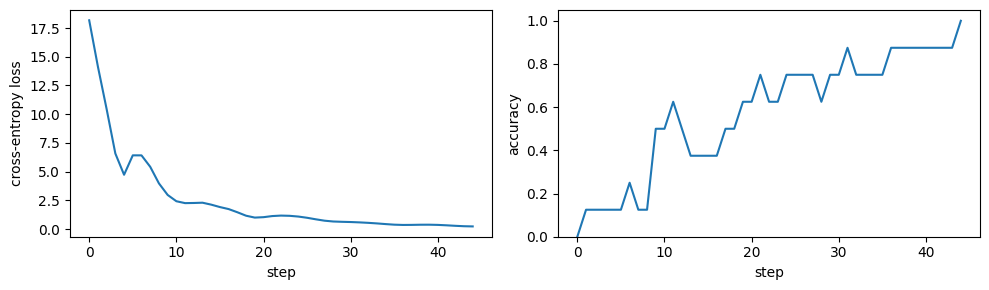


[OK] Checkpoint C: equivariant network classifies all 8 Tetris shapes, including the chiral pair.


In [10]:
import time

class Layer(nn.Module):
    target_irreps: str
    denominator: float
    sh_lmax: int = 3

    @nn.compact
    def __call__(self, gr, positions):
        target = e3nn.Irreps(self.target_irreps)

        def update_edge_fn(edge, sender, receiver, glob):
            # `positions` is an IrrepsArray('1o'), so subtraction yields IrrepsArray('1o')
            # which spherical_harmonics accepts directly (required in e3nn-jax 0.21).
            rij = positions[gr.receivers] - positions[gr.senders]
            sh = e3nn.spherical_harmonics(
                list(range(1, self.sh_lmax + 1)), rij, True,
            )
            return e3nn.concatenate([sender, e3nn.tensor_product(sender, sh)]).regroup()

        def update_node_fn(node, sender_msg, receiver_msg, glob):
            x = receiver_msg / self.denominator
            x = e3nn.flax.Linear(target, name="lin_pre")(x)
            x = e3nn.scalar_activation(x)
            x = e3nn.flax.Linear(target, name="lin_post")(x)
            short = e3nn.flax.Linear(x.irreps, name="shortcut", force_irreps_out=True)(node)
            return short + x

        return jraph.GraphNetwork(update_edge_fn, update_node_fn)(gr)


class TetrisModel(nn.Module):
    @nn.compact
    def __call__(self, gr):
        positions = e3nn.IrrepsArray("1o", gr.nodes)
        gr = gr._replace(nodes=jnp.ones((len(positions), 1)))
        layers = 2 * ["32x0e + 32x0o + 8x1e + 8x1o + 8x2e + 8x2o"] + ["0o + 7x0e"]
        for irreps in layers:
            gr = Layer(irreps, 1.5)(gr, positions)

        # Pool per graph: sum atomic features into shape (num_graphs, 8).
        pred = e3nn.scatter_sum(gr.nodes.array, nel=gr.n_node)

        # The last layer's irreps were "0o + 7x0e". The 8 features per graph are:
        #   pred[:, 0]   = the 0o (parity-odd scalar). It flips sign on reflection.
        #                  This is what tells chiral_1 from chiral_2.
        #   pred[:, 1]   = a 0e magnitude paired with the 0o for the chiral logits.
        #   pred[:, 2:8] = six 0e logits, one for each non-chiral class.
        # We then build 8 class logits in label order
        # [chiral_1, chiral_2, square, line, corner, L, T, zigzag]:
        odd, even1, even2 = pred[:, :1], pred[:, 1:2], pred[:, 2:]
        logits = jnp.concatenate([odd * even1, -odd * even1, even2], axis=1)
        return logits


model = TetrisModel()
opt = optax.adam(0.01)

def loss_fn(params, gr):
    logits = model.apply(params, gr)
    labs = gr.globals
    loss = jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, labs))
    return loss, logits

@jax.jit
def step(params, opt_state, gr):
    grads, logits = jax.grad(loss_fn, has_aux=True)(params, gr)
    acc = jnp.mean(jnp.argmax(logits, axis=1) == gr.globals)
    updates, opt_state = opt.update(grads, opt_state)
    return optax.apply_updates(params, updates), opt_state, acc, logits

params = jax.jit(model.init)(jax.random.PRNGKey(SEED), graphs)
opt_state = opt.init(params)

wall = time.perf_counter()
print("JIT-compiling step (this can take 30-90 s on first call)...")
params, opt_state, acc, logits = step(params, opt_state, graphs)
print(f"compile + first step: {time.perf_counter() - wall:.1f} s, initial acc = {100*acc:.0f}%")

loss_hist, acc_hist = [], []
for s in tqdm(range(200)):
    params, opt_state, acc, logits = step(params, opt_state, graphs)
    loss_val, _ = loss_fn(params, graphs)
    loss_hist.append(float(loss_val))
    acc_hist.append(float(acc))
    if acc == 1.0:
        print(f"\nReached 100% accuracy at step {s}")
        break

print(f"final training accuracy: {100*acc_hist[-1]:.0f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(loss_hist); axes[0].set_xlabel("step"); axes[0].set_ylabel("cross-entropy loss")
axes[1].plot(acc_hist); axes[1].set_xlabel("step"); axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()
print("\n[OK] Checkpoint C: equivariant network classifies all 8 Tetris shapes, including the chiral pair.")

## Cell 11. The real test. Does it still work after rotation

The equivariant model trained on each shape exactly once, with no rotated copies. Now the test that an ordinary network cannot pass.

**Part 1. Rotation test on the equivariant model.** Take all 8 shapes, rotate by 100 random matrices, classify each rotated copy. Expected accuracy is 100%. Rotation does not change the model's output by construction.

**Part 2. Vanilla MLP baseline.** Train a 3-layer MLP on the same 8 flat-coordinate inputs. Run the same rotation test. Expected accuracy is about

$$\frac{1}{8} \;\approx\; 12.5\%,$$

the random-guessing rate. The MLP has no built-in notion of rotation. (This reproduces the L11 finding for completeness, this time alongside an equivariant network on the same axes.)

This is the data-efficiency claim in miniature. To match the equivariant model's rotation behavior with a vanilla MLP, you would need hundreds to thousands of rotated copies of each shape in the training set.

![accuracy comparison bar chart, equivariant vs vanilla MLP.](https://yw-choi.github.io/PHYG004/lectures/12/images/10_accuracy_comparison.png)


In [11]:
# Part 1: equivariance test
def rotate_graphs(gr: jraph.GraphsTuple, R: jnp.ndarray) -> jraph.GraphsTuple:
    return gr._replace(nodes=gr.nodes @ R.T)

@jax.jit
def predict(params, gr):
    return jnp.argmax(model.apply(params, gr), axis=1)

base_pred = predict(params, graphs)
n_test = 100
rot_keys = jax.random.split(jax.random.PRNGKey(99), n_test)
rot_acc = []
for k in rot_keys:
    R = e3nn.rand_matrix(k)
    pred = predict(params, rotate_graphs(graphs, R))
    rot_acc.append(float(jnp.mean(pred == graphs.globals)))
rot_acc = np.array(rot_acc)
print(f"equivariant net rotated-test accuracy: mean = {rot_acc.mean()*100:.1f}%, min = {rot_acc.min()*100:.1f}%")
assert rot_acc.mean() > 0.99, "equivariance broken"
print("✅ Equivariant network: rotation-invariant predictions, as designed.")

equivariant net rotated-test accuracy: mean = 100.0%, min = 100.0%
✅ Equivariant network: rotation-invariant predictions, as designed.


  0%|          | 0/1000 [00:00<?, ?it/s]

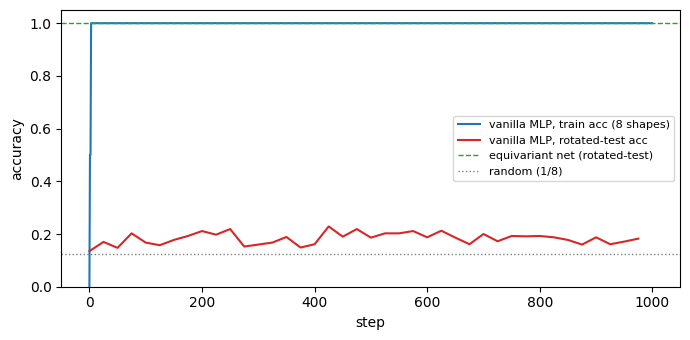

vanilla MLP final train acc       : 100%
vanilla MLP final rotated-test acc: 18%   (≈ random)

The MLP memorizes the 8 training shapes. It has no idea what to do with rotated copies. That is exactly the gap equivariance closes.


In [12]:
# Part 2: vanilla MLP baseline trained on flat coordinates
X_train = pos.reshape(8, 12)             # flatten 4 atoms × 3 coords
y_train = labels

class MLP(nn.Module):
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(128)(x); x = nn.silu(x)
        x = nn.Dense(128)(x); x = nn.silu(x)
        return nn.Dense(8)(x)

mlp = MLP()
mlp_params = mlp.init(jax.random.PRNGKey(0), X_train)
mlp_opt = optax.adam(0.01)
mlp_state = mlp_opt.init(mlp_params)

@jax.jit
def mlp_step(params, state, X, y):
    def loss_fn(p):
        logits = mlp.apply(p, X)
        return jnp.mean(optax.softmax_cross_entropy_with_integer_labels(logits, y)), logits
    grads, logits = jax.grad(loss_fn, has_aux=True)(params)
    updates, state = mlp_opt.update(grads, state)
    return optax.apply_updates(params, updates), state, jnp.mean(jnp.argmax(logits, axis=1) == y)

train_acc_hist, rot_acc_hist = [], []
for s in tqdm(range(1000)):
    mlp_params, mlp_state, train_acc = mlp_step(mlp_params, mlp_state, X_train, y_train)
    if s % 25 == 0:
        # rotated-test accuracy: 100 random rotations of the training shapes
        rks = jax.random.split(jax.random.PRNGKey(123 + s), 100)
        accs = []
        for k in rks:
            R = e3nn.rand_matrix(k)
            X_rot = (pos @ R.T).reshape(8, 12)
            preds = jnp.argmax(mlp.apply(mlp_params, X_rot), axis=1)
            accs.append(float(jnp.mean(preds == labels)))
        rot_acc_hist.append((s, np.mean(accs)))
    train_acc_hist.append((s, float(train_acc)))

ts, tas = zip(*train_acc_hist)
rs, ras = zip(*rot_acc_hist)
plt.figure(figsize=(7, 3.5))
plt.plot(ts, tas, label="vanilla MLP, train acc (8 shapes)", color="C0")
plt.plot(rs, ras, label="vanilla MLP, rotated-test acc", color="C3")
plt.axhline(1.0, color="C2", ls="--", lw=1, label="equivariant net (rotated-test)")
plt.axhline(1/8, color="gray", ls=":", lw=1, label="random (1/8)")
plt.xlabel("step"); plt.ylabel("accuracy"); plt.ylim(0, 1.05)
plt.legend(loc="center right", fontsize=8); plt.tight_layout(); plt.show()

print(f"vanilla MLP final train acc       : {train_acc_hist[-1][1]*100:.0f}%")
print(f"vanilla MLP final rotated-test acc: {rot_acc_hist[-1][1]*100:.0f}%   (≈ random)")
print("\nThe MLP memorizes the 8 training shapes. It has no idea what to do with rotated copies. That is exactly the gap equivariance closes.")

## Recap

We reproduced Thomas et al. 2018 *Tensor Field Networks* Section 4.1 in 75 minutes.

| Result | Why it works |
|---|---|
| 8 shapes classified from 8 training examples | every layer is rotation-equivariant by construction |
| Chiral pair distinguished | `0o` parity-odd output channel flips sign under reflection |
| 100% accuracy on 100 random rotations | rotation does not change outputs by construction |
| Vanilla MLP collapses to about 12% on rotated test | no symmetry baked in |

## Why this scales

Modern molecular simulation uses this same recipe at full size.

* **NequIP** (Batzner et al. 2022). Equivariant message-passing for atomic potentials. Matches state-of-the-art accuracy with 100 to 1000 times less training data than non-equivariant baselines on MD-17 and liquid water.
* **MACE** (Batatia et al. 2022). Same family. Carries up to 4-body correlations in one layer.
* **MACE-MP-0** (2023). A foundation model covering 89 elements. Available on Hugging Face as `mace-mp-0`.

For molecules, materials, and drug discovery, the data-efficiency gap is decisive. Generating training data costs CPU-millennia of DFT.

* NequIP repository. <https://github.com/mir-group/nequip>
* MACE repository. <https://github.com/ACEsuit/mace>
* MACE-MP-0 on Hugging Face.

## Optional take-home exercises

**1. Swap the chiral labels.** In the dataset cell, swap the labels of `chiral_1` and `chiral_2`, then retrain. Does the network still hit 100%?

The answer is yes. The model learns the opposite sign on the `0o` channel.

**2. Remove the `0o` channel.** Change the last layer's irreps from `"0o + 7x0e"` to `"7x0e"`. Retrain.

The chiral pair becomes impossible to distinguish. The model has no parity-odd feature left, so no internal quantity flips sign under reflection. This shows concretely that the `0o` channel is the carrier of chirality information.

![lineage from TFN to NequIP, MACE, and MACE-MP-0.](https://yw-choi.github.io/PHYG004/lectures/12/images/wrap_lineage.png)
